# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Климчук Юрій'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 9     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Климчук Юрій, ШІ-31, варіант 9
ваш потік:                   P>50
ваша пара для графіка 3:     потік E>0.8 та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel('20171129_FINAL_FINAL.xlsx', sheet_name='Sheet1')

print("Перші рядки:")
print(df.head())

print("\nТипи стовпців:")
print(df.dtypes)

Перші рядки:
   Unnamed: 0        ftp://ftp.swpc.noaa.gov/pub/lists/particle/ Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0         NaN                                                NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
1         NaN                :Data_list: 20170901_Gs_part_5m.txt        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
2         NaN                     :Created: 2017 Sep 02 0011 UTC        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
3         NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
4         NaN  # Please sen

**Відповідь 1.1:** *Такий результат виникає через те, що файл не є стандартною простою таблицею, де рядок 1 містить назви колонок, а наступні колонки - це дані. При виклику pd.read_excel(ФАЙЛ) за замовчуванням стоїть параметр header=0, тобто перший рядок файлу вважається заголовками.
У наведеному документі у першому рядку є лише 2 посилання, а усе інше - пусті клітинки, так і наступні клітинки в основному пусті(окрім кількох заповнених текстом), тому їхній вміст і було виведено як NaN.
Якщо ж подивитися на вивід, який позначає типи Перших стовпців то більшість з них є Unnamed, бо не мають вмісту у першому рядку таблиці. Більшість стовпців позначенні типом object оскільки містять текстові дані у наступних рядках, ті що позначені як float64 - не містять жодного елемента, отже повністю заповненні значенням NaN, який має тип float64.*

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel('20171129_FINAL_FINAL.xlsx', sheet_name='Sheet1', header=None)

print("Розмір:", RAW.shape)
RAW.head(30)

Розмір: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
filled_counts = RAW.notna().sum()
print(filled_counts)

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *Таблиць у записі 3*
 - Перша таблиця знаходиться на стовпцях 1-14 оскільки можна помітити, що там кількість записів ~7200. З цього можна зробити висновок, що таблиця має приблизно 7200 рядків(7198 якщо бути точним).
 - Друга таблиця знаходиться на стовпцях 16-19 оскільки можна помітити, що там кількість записів ~30. З цього можна зробити висновок, що таблиця має 26 рядків(16 стовпець містить заповнені клітинки, що не є частиною таблиці).
 - Третя таблиця знаходиться на стовпцях 24-31 оскільки можна помітити, що там кількість записів ~600. З цього можна зробити висновок, що таблиця має приблизно 600 рядків.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print("Таблиця 1 (стовпчик 1)")
print(RAW.iloc[0:23, 1].dropna().to_string(index=False))

print("\nТаблиця 2 (стовпчик 16)")
print(RAW.iloc[12:24, 16].dropna().to_string(index=False))

print("\nТаблиця 3 (стовпчик 26)")
print(RAW.iloc[0:8, 26].dropna().to_string(index=False))

Таблиця 1 (стовпчик 1)
       ftp://ftp.swpc.noaa.gov/pub/lists/particle/
               :Data_list: 20170901_Gs_part_5m.txt
                    :Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA,...
# Please send comments and suggestions to SWPC....
                                                # 
              # Label: P > 1 = Particles at >1 Mev
              # Label: P > 5 = Particles at >5 Mev
             # Label: P >10 = Particles at >10 Mev
             # Label: P >30 = Particles at >30 Mev
             # Label: P >50 = Particles at >50 Mev
            # Label: P>100 = Particles at >100 Mev
            # Label: E>0.8 = Electrons at >0.8 Mev
            # Label: E>2.0 = Electrons at >2.0 Mev
            # Label: E>4.0 = Electrons at >4.0 Mev
             # Units: Particles = Protons/cm2-s-sr
           # Units: Electrons = Electrons/cm2-s-sr
                                 # Source: GOES-15
                                  # Location: W135
        

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання                                                                                                                                                  |
|---|---|----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| A | ftp://ftp.swpc.noaa.gov/pub/lists/particle/ | Protons/(cm^2 * s * sr)(протони на квадратний сантиметр за секунду на стерадіан); Electrons/(cm^2 * s * sr)(електрони на квадратний сантиметр за секунду на стерадіан) |
| B | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices | Radio Flux 10.7 (сонячний радіопотік на довжині хвилі 10.7 см):sfu(solar flux unit), де 1 sfu = 10^-22 W/ (m^2 * Hz)                                                 |
| C | http://umtof.umd.edu/pm/crn/ | Швидкість сонячного вітру/протонів: km/sec(кілометри за секунду).Густина протонів: protons/cm^3(протони на кубічний сантиметр)                                       |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].copy()
A.columns = [
    'year', 'month', 'day', 'time_hhmm', 'julian_day', 'seconds_of_day',
    'p_gt_1', 'p_gt_5', 'p_gt_10', 'p_gt_30', 'p_gt_50', 'p_gt_100',
    'e_gt_0_8', 'e_gt_2_0'
]
A = A.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

B = RAW.iloc[27:52, 16:20].copy()
B.columns = ['year', 'month', 'day', 'radio_flux_10_7']
B = B.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

C = RAW.iloc[27:628, 24:32].copy()
C.columns = ['idx1', 'idx2', 'year', 'month', 'day', 'hour', 'speed', 'density']
C = C.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
A['ts'] = pd.to_datetime({
    'year': A['year'],
    'month': A['month'],
    'day': A['day'],
    'hour': A['time_hhmm'] // 100,
    'minute': A['time_hhmm'] % 100
})

B['ts'] = pd.to_datetime({
    'year': B['year'],
    'month': B['month'],
    'day': B['day']
})

C['ts'] = pd.to_datetime({
    'year': C['year'] + 2000,
    'month': C['month'],
    'day': C['day'],
    'hour': C['hour']
})

for name, df in [('Таблиця A (GOES-15)', A), ('Таблиця B (Radio Flux)', B), ('Таблиця C (SOHO)', C)]:
    print(f"{name}:")
    print(f"Найраніша дата: {df['ts'].min()}")
    print(f"Найпізніша дата: {df['ts'].max()}\n")


Таблиця A (GOES-15):
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-21 23:55:00

Таблиця B (Radio Flux):
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-21 00:00:00

Таблиця C (SOHO):
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-22 00:00:00



**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
tables = [("Таблиця A (GOES-15)", A), ("Таблиця B (Radio Flux)", B), ("Таблиця C (SOHO)", C)]

for name, df in tables:
    print(f"{name}")
    print(f"1.Розмір (рядків, стовпців): {df.shape}")
    print(f"2.Кількість повних дублікатів: {df.duplicated().sum()}")

    print("\n3.Кількість пропусків у стовпцях:")
    print(df.isna().sum())

    print("\n4.Типи даних стовпців:")
    print(df.dtypes)

    print("\n5.Описові статистики (describe):")
    display(df.describe())
    print("\n")

Таблиця A (GOES-15)
1.Розмір (рядків, стовпців): (7200, 15)
2.Кількість повних дублікатів: 0

3.Кількість пропусків у стовпцях:
year              0
month             0
day               0
time_hhmm         0
julian_day        0
seconds_of_day    0
p_gt_1            3
p_gt_5            3
p_gt_10           3
p_gt_30           3
p_gt_50           3
p_gt_100          3
e_gt_0_8          3
e_gt_2_0          3
ts                0
dtype: int64

4.Типи даних стовпців:
year                       int64
month                      int64
day                        int64
time_hhmm                  int64
julian_day                 int64
seconds_of_day             int64
p_gt_1                   float64
p_gt_5                   float64
p_gt_10                  float64
p_gt_30                  float64
p_gt_50                  float64
p_gt_100                 float64
e_gt_0_8                 float64
e_gt_2_0                 float64
ts                datetime64[us]
dtype: object

5.Описові статистики (des

,year,month,day,time_hhmm,julian_day,seconds_of_day,p_gt_1,p_gt_5,p_gt_10,p_gt_30,p_gt_50,p_gt_100,e_gt_0_8,e_gt_2_0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN




Таблиця B (Radio Flux)
1.Розмір (рядків, стовпців): (25, 5)
2.Кількість повних дублікатів: 0

3.Кількість пропусків у стовпцях:
year               0
month              0
day                0
radio_flux_10_7    0
ts                 0
dtype: int64

4.Типи даних стовпців:
year                        int64
month                       int64
day                         int64
radio_flux_10_7             int64
ts                 datetime64[us]
dtype: object

5.Описові статистики (describe):


,year,month,day,radio_flux_10_7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN




Таблиця C (SOHO)
1.Розмір (рядків, стовпців): (601, 9)
2.Кількість повних дублікатів: 0

3.Кількість пропусків у стовпцях:
idx1       0
idx2       0
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0
dtype: int64

4.Типи даних стовпців:
idx1              float64
idx2              float64
year                int64
month               int64
day                 int64
hour                int64
speed               int64
density           float64
ts         datetime64[us]
dtype: object

5.Описові статистики (describe):


,idx1,idx2,year,month,day,hour,speed,density,ts
count,601.000000,601.000000,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,11.480865,11.480865,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,0.000000,0.000000,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,5.000000,5.000000,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,11.000000,11.000000,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.000000,17.000000,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,23.000000,23.000000,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,6.938063,6.938063,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# Відновлення початкового значення таблиці C для повторного записку клітинки знизу
C = RAW.iloc[27:628, 24:32].copy()
C.columns = ['idx1', 'idx2', 'year', 'month', 'day', 'hour', 'speed', 'density']
C = C.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
C['ts'] = pd.to_datetime({
    'year': C['year'] + 2000,
    'month': C['month'],
    'day': C['day'],
    'hour': C['hour']
})

In [13]:
# ВАШ КОД
neg_speed = (C['speed'] < 0).sum()
neg_density = (C['density'] < 0).sum()
print(f"Кількість від'ємних значень у speed: {neg_speed}")
print(f"Кількість від'ємних значень у density: {neg_density}")

speed_min_before = C['speed'].min()
speed_mean_before = C['speed'].mean()
density_min_before = C['density'].min()
density_mean_before = C['density'].mean()

C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

speed_min_after = C['speed'].min()
speed_mean_after = C['speed'].mean()
density_min_after = C['density'].min()
density_mean_after = C['density'].mean()

print("\nРезультати зміни статистики")
print(f"speed:\nmin: {speed_min_before} -> {speed_min_after:.2f} | mean: {speed_mean_before:.2f} -> {speed_mean_after:.2f}\n")
print(f"density:\nmin: {density_min_before} -> {density_min_after:.2f} | mean: {density_mean_before:.2f} -> {density_mean_after:.2f}")

Кількість від'ємних значень у speed: 8
Кількість від'ємних значень у density: 8

Результати зміни статистики
speed:
min: -1 -> 277.00 | mean: 506.55 -> 513.39

density:
min: -1.0 -> 0.10 | mean: 2.91 -> 2.96


**Відповідь 3.2:**

*Що це за значення: Значення -1 (або -1.0) у стовпцях швидкості (speed) та густини (density) є технічним прапорцем відсутності даних (missing data flag) з боку приладу SOHO CELIAS. Оскільки фізично швидкість і густина не можуть бути від'ємними, прилад позначає цим числом інтервали, коли спостереження не проводилися, датчик був на калібруванні або потік частинок не вдалося зареєструвати.

У таблиці C виявлено по 8 таких значень в обох стовпцях (усі вони збігаються за часовими інтервалами). Оскільки значення -1 є фіктивними від'ємними числами, вони занижували вибіркове середнє значення. Для speed середнє було штучно занижене на ~6.84 км/с(зросло з 506.55 до 513.39 км/с після фільтрації). Для density середнє було занижене на ~0.05 протон/см}^3(зросло з 2.91 до 2.96 протон/см^3). Окрім цього, наявність -1 спотворювала мінімуми вибірки, приховуючи реальні мінімальні фізичні показники (277.0 км/с та 0.1 протон/см^3). Заміна на NaN повернула правдивість описовим метрикам вибірки.*

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [14]:
# ВАШ КОД
time_index_cols = ['year', 'month', 'day', 'time_hhmm','julian_day', 'seconds_of_day']
meaningless_stats = A[time_index_cols].describe().loc[['mean', 'std', 'min', 'max']]

print("Статистика для стовпців часових міток:")
display(meaningless_stats)

Статистика для стовпців часових міток:


,year,month,day,time_hhmm,julian_day,seconds_of_day
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


**Відповідь 3.3:** *У таблиці A є часові та календарні дані, для яких не усі числові метрики несуть сенс*
 - time_hhmm - форматний час доби. Значення середнього 1177.5 позбавлене будь-якого фізичного змісту. Час кодується у системі числення за основою 60 (в годині 60 хвилин, а не 100), тому проміжок між 1159 та 1200 має стрибок на 41 пункт, який є просто наслідком числення до 60, а не до 100. Так отримане середнє значення 1177.5 взагалі не існує на годиннику. По тим же причинам значення стандартного відхилення не є змістовним. А от значення min та max чітко вказують найраніший запис і найпізніший запис часу доби

 - year, month, day - календарні координати. Числа на кшталт "місяць 8.84" або "день 13.96" не є фізичними величинами, тому не несуть жодного сенсу. Стандартне відхилення теж не є релевантним так як це відліки часу. Мінімальне і максимальне значення просто встановлюють календарні межі.

 - julian_day та seconds_of_day - умовний відлік днів та час доби у секундах. Хоча секунди є лінійною шкалою, середня секунда 43050.0 (що відповідає рівно 11:57:30) — це просто артефакт строго рівномірного збору даних кожні 5 хвилин із півночі до кінця доби, а не результат статистичного розподілу випадкової величини. А метрики для юліанського дня не маю свого початкового сенсу, так як це послідовний відлік, а не певний набір числових значень

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [15]:
# ВАШ КОД
flux_cols = [
    'p_gt_1', 'p_gt_5', 'p_gt_10', 'p_gt_30',
    'p_gt_50', 'p_gt_100', 'e_gt_0_8', 'e_gt_2_0'
]

A_hourly = (
    A.set_index('ts')[flux_cols]
    .resample('1h')
    .agg(['mean', 'max'])
)

A_hourly.columns = [f"{col}_{stat}" for col, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print(f"Розмір A_hourly: {A_hourly.shape}")
A_hourly


Розмір A_hourly: (600, 17)


,ts,p_gt_1_mean,p_gt_1_max,p_gt_5_mean,p_gt_5_max,p_gt_10_mean,p_gt_10_max,p_gt_30_mean,p_gt_30_max,p_gt_50_mean,p_gt_50_max,p_gt_100_mean,p_gt_100_max,e_gt_0_8_mean,e_gt_0_8_max,e_gt_2_0_mean,e_gt_2_0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2017-09-21 19:00:00,63.166667,93.10,0.372500,0.795,0.229833,0.472,0.110642,0.1570,0.074300,0.1050,0.040192,0.0687,180250.000000,186000.0,65750.000000,66800.0
596,2017-09-21 20:00:00,42.102500,78.90,0.397500,0.833,0.226833,0.429,0.089325,0.1380,0.069983,0.1050,0.039692,0.0737,178750.000000,186000.0,63175.000000,70500.0
597,2017-09-21 21:00:00,50.783333,71.70,0.489250,0.788,0.317583,0.501,0.121358,0.2040,0.077467,0.1470,0.033417,0.0524,175833.333333,177000.0,58350.000000,60300.0
598,2017-09-21 22:00:00,39.000000,48.80,0.350000,0.536,0.200250,0.310,0.094358,0.1430,0.070633,0.1080,0.039600,0.0798,167750.000000,176000.0,49366.666667,54400.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

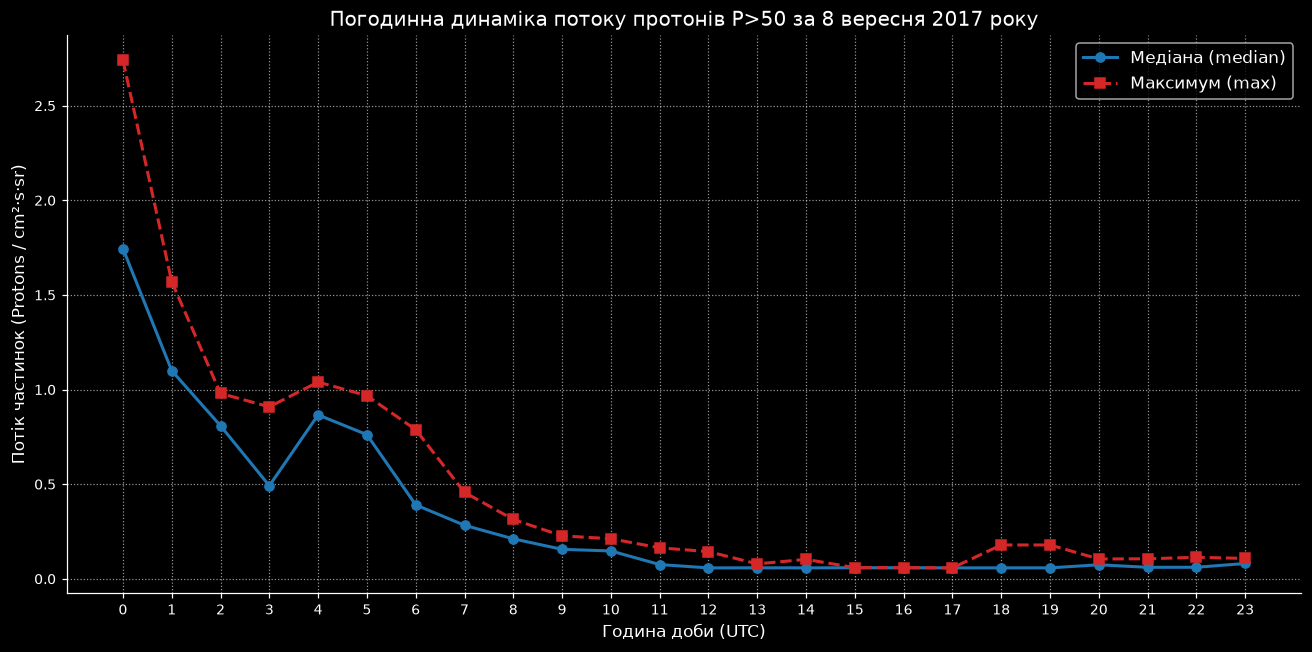

In [16]:
day_mask = (A['ts'] >= '2017-09-08') & (A['ts'] < '2017-09-09')
df_day = A[day_mask].copy()

p50_hourly = (
    df_day.set_index('ts')['p_gt_50']
    .resample('1h')
    .agg(['median', 'max'])
)

plt.figure(figsize=(12, 6))
plt.plot(p50_hourly.index.hour, p50_hourly['median'], label='Медіана (median)', marker='o', linewidth=2, color='tab:blue')
plt.plot(p50_hourly.index.hour, p50_hourly['max'], label='Максимум (max)', marker='s', linestyle='--', linewidth=2, color='tab:red')

plt.title('Погодинна динаміка потоку протонів P>50 за 8 вересня 2017 року', fontsize=13)
plt.xlabel('Година доби (UTC)', fontsize=11)
plt.ylabel('Потік частинок (Protons / cm²·s·sr)', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *Крива максимуму завжди проходить вище за криву медіани, оскільки вона показує найсильніший одиничний сплеск випромінювання за кожну годину, тоді як медіана відображає типовий стабільний рівень потоку, відсікаючи аномалії. Різниця між ними стає найбільш помітною та важливою в періоди різких змін або спалахів, як от на початку доби з 0 до 6 години, коли потік швидко спадає або коливається, тоді як під час спокійного стану з 12 до 23 години обидва показники практично зливаються біля фонових значень; це важливо враховувати, оскільки медіана краще показує загальний фоновий стан середовища, а максимум дозволяє вчасно помітити критичні короткочасні перевантаження обладнання.*

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [17]:
# ВАШ КОД
A_hourly['date'] = A_hourly['ts'].dt.floor('D')
C_clean = C[['ts', 'speed', 'density']].copy()
C_clean['date'] = C_clean['ts'].dt.floor('D')
B_daily = B[['ts', 'radio_flux_10_7']].copy()
B_daily['date'] = B_daily['ts'].dt.floor('D')

M_inner = pd.merge(A_hourly.drop(columns=['date']), C_clean.drop(columns=['date']), on='ts', how='inner')
M_inner['date'] = M_inner['ts'].dt.floor('D')
M_inner = pd.merge(M_inner, B_daily[['date', 'radio_flux_10_7']], on='date', how='inner').drop(columns=['date'])

M_outer = pd.merge(A_hourly.drop(columns=['date']), C_clean.drop(columns=['date']), on='ts', how='outer')
M_outer['date'] = M_outer['ts'].dt.floor('D')
M_outer = pd.merge(M_outer, B_daily[['date', 'radio_flux_10_7']], on='date', how='left').drop(columns=['date'])

print(f"Розмір M (inner): {M_inner.shape}")
print(f"Розмір M (outer): {M_outer.shape}")

M = M_inner

print(f"Розмір підсумкової таблиці M: {M.shape}")

nan_rows = M[M.isna().any(axis=1)]
print(f"\nКількість рядків із пропусками: {len(nan_rows)}")
nan_rows

Розмір M (inner): (600, 20)
Розмір M (outer): (601, 20)
Розмір підсумкової таблиці M: (600, 20)

Кількість рядків із пропусками: 8


,ts,p_gt_1_mean,p_gt_1_max,p_gt_5_mean,p_gt_5_max,p_gt_10_mean,p_gt_10_max,p_gt_30_mean,p_gt_30_max,p_gt_50_mean,p_gt_50_max,p_gt_100_mean,p_gt_100_max,e_gt_0_8_mean,e_gt_0_8_max,e_gt_2_0_mean,e_gt_2_0_max,speed,density,radio_flux_10_7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140


**Відповідь 4.3:** *Для фінальної таблиці обрано тип inner, який дає рівно 600 рядків, оскільки він залишає тільки спільний для всіх трьох приладів часовий інтервал у 25 повних діб, тоді як варіант outer створює 601 рядок через один зайвий нічний запис у таблиці C за 22 вересня. Цей останній рядок не має практичного змісту для подальшого аналізу, адже в ньому повністю відсутні вимірювання супутника GOES-15 та сонячного радіопотоку, а inner дозволяє отримати чисту узгоджену сітку, де пропуски залишаються лише у восьми рядках через реальну технічну паузу в роботі детектора SOHO.*

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [18]:
# ВАШ КОД
bins = [-np.inf, 10, 1000, np.inf]
labels = ['тиха', 'активна', 'дуже активна']

M['група'] = pd.cut(M['p_gt_10_max'], bins=bins, labels=labels, right=False)

print("Кількість годин у кожній групі:")
print(M['група'].value_counts())


Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [19]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє (mean): 7.4439 Protons / (cm²·s·sr)
Медіана (median): 0.0802 Protons / (cm²·s·sr)


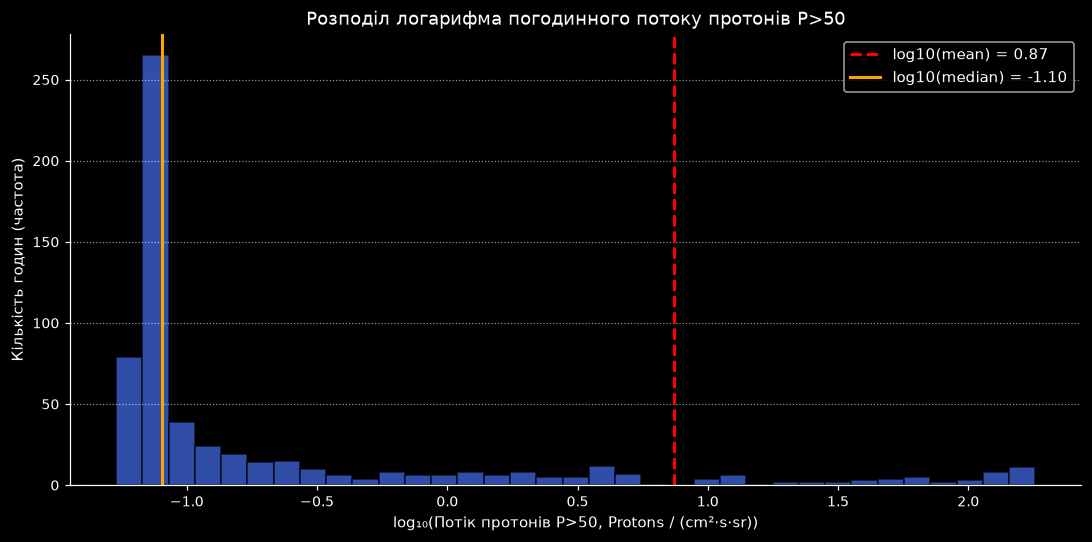

In [20]:
# ВАШ КОД
mean_val = M['p_gt_50_mean'].mean()
median_val = M['p_gt_50_mean'].median()

print(f"Середнє (mean): {mean_val:.4f} Protons / (cm²·s·sr)")
print(f"Медіана (median): {median_val:.4f} Protons / (cm²·s·sr)")

log_values = np.log10(M['p_gt_50_mean'].dropna())

plt.figure(figsize=(10, 5))
plt.hist(log_values, bins=35, edgecolor='black', alpha=0.75, color='royalblue')

plt.axvline(np.log10(mean_val), color='red', linestyle='--', linewidth=2, label=f'log10(mean) = {np.log10(mean_val):.2f}')
plt.axvline(np.log10(median_val), color='orange', linestyle='-', linewidth=2, label=f'log10(median) = {np.log10(median_val):.2f}')

plt.title('Розподіл логарифма погодинного потоку протонів P>50', fontsize=12)
plt.xlabel('log₁₀(Потік протонів P>50, Protons / (cm²·s·sr))', fontsize=10)
plt.ylabel('Кількість годин (частота)', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Висновок:**
Переважну більшість часу потік протонів P>50 перебуває на спокійному фоновому рівні біля 0.08, проте поодинокі сонячні спалахи породжують викиди до сотень одиниць, через що середнє значення виявляється майже у 90 разів вищим за типову медіану.
Середнє та медіана настільки кардинально відрізняються через екстремальну правосторонню скошеність медіана фіксує найтиповіший спокійний стан середовища і є нечутливою до сплесків, тоді як арифметичне середнє сильно зміщується вгору через кілька десятків годин потужних спалахів із концентраціями, що перевищують фон у тисячі разів.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

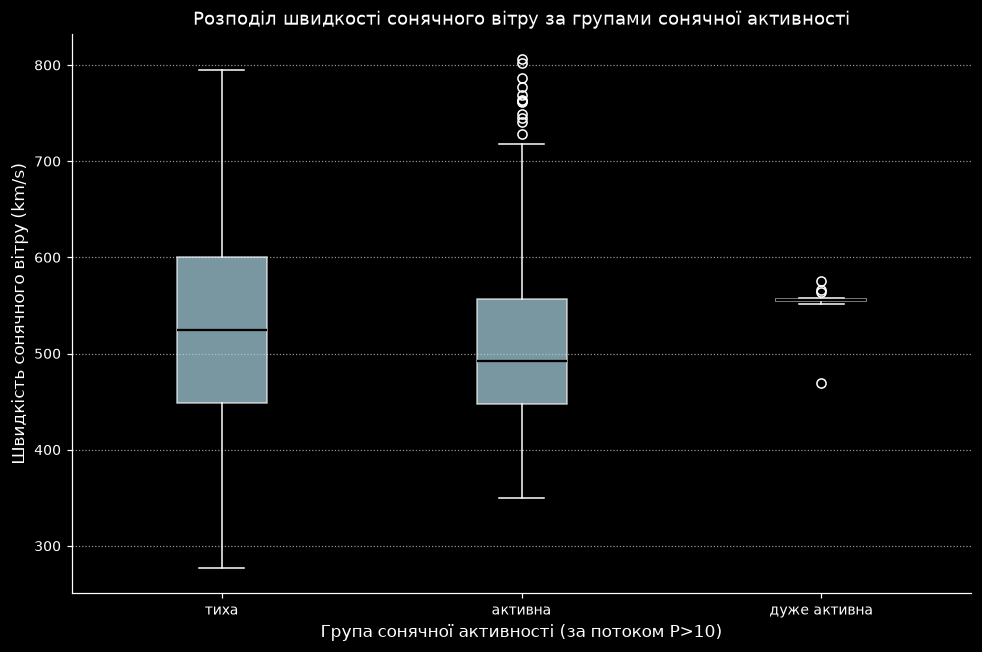

In [21]:
# ВАШ КОД
groups_order = ['тиха', 'активна', 'дуже активна']
data_to_plot = [
    M.loc[M['група'] == grp, 'speed'].dropna()
    for grp in groups_order
]

plt.figure(figsize=(9, 6))
box = plt.boxplot(
    data_to_plot,
    tick_labels=groups_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(facecolor='lightblue', alpha=0.7)
)

plt.title('Розподіл швидкості сонячного вітру за групами сонячної активності', fontsize=12)
plt.xlabel('Група сонячної активності (за потоком P>10)', fontsize=11)
plt.ylabel('Швидкість сонячного вітру (km/s)', fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**
Оскільки медіана "активної" групи виявилася навіть нижчою за "тиху"(~490км/с проти ~525км/с), зв'язок між медіаною швидкістю вітру та групами не є лінійним. Медіанні швидкості вітру для "тихих" і "активних" годин суттєво не відрізняються (тримаються в межах 490–525 км/с), проте саме в "активну" фазу з'являється велика кількість екстремальних викидів швидкості понад 750–800 км/с. Тоді як у "дуже активній" групі швидкість стабілізується біля 555 км/с із мінімальною варіацією

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона (Pearson): -0.0495
Коефіцієнт кореляції Спірмена (Spearman): -0.0041


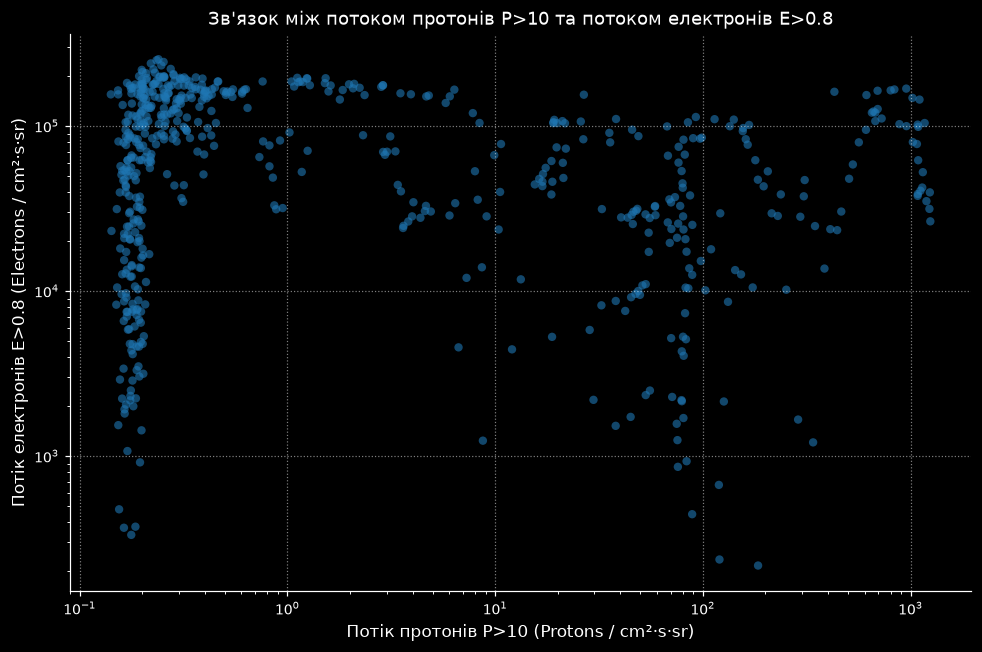

In [22]:
# ВАШ КОД
pair_df = M[['e_gt_0_8_mean', 'p_gt_10_mean']].dropna()

corr_pearson = pair_df['e_gt_0_8_mean'].corr(pair_df['p_gt_10_mean'], method='pearson')
corr_spearman = pair_df['e_gt_0_8_mean'].corr(pair_df['p_gt_10_mean'], method='spearman')

print(f"Коефіцієнт кореляції Пірсона (Pearson): {corr_pearson:.4f}")
print(f"Коефіцієнт кореляції Спірмена (Spearman): {corr_spearman:.4f}")

plt.figure(figsize=(9, 6))
plt.scatter(
    pair_df['p_gt_10_mean'],
    pair_df['e_gt_0_8_mean'],
    alpha=0.6,
    edgecolors='none',
    color='tab:blue',
    s=30
)

plt.xscale('log')
plt.yscale('log')

plt.title('Зв\'язок між потоком протонів P>10 та потоком електронів E>0.8', fontsize=12)
plt.xlabel('Потік протонів P>10 (Protons / cm²·s·sr)', fontsize=11)
plt.ylabel('Потік електронів E>0.8 (Electrons / cm²·s·sr)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Висновок:**
Між потоком протонів P>10 та електронів E>0.8 спостерігається нелінійний зв'язок: у спокійні періоди потік протонів залишається практично сталим незалежно від коливань електронів, проте під час потужних спалахів обидві величини синхронно зростають на кілька порядків.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

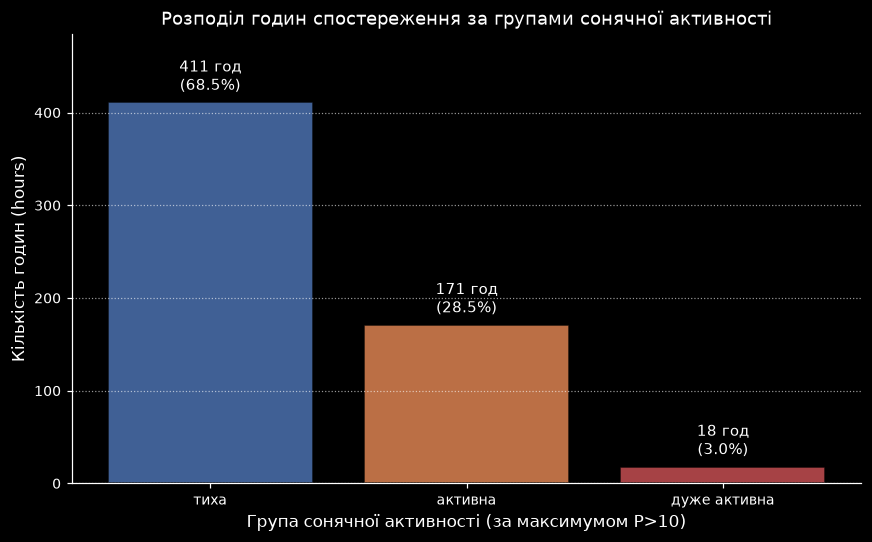

In [23]:
# ВАШ КОД

groups_order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts()[groups_order]
total_hours = len(M)

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#C44E52'], edgecolor='black', alpha=0.85)

for bar in bars:
    height = bar.get_height()
    percent = (height / total_hours) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8,
        f"{int(height)} год\n({percent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Розподіл годин спостереження за групами сонячної активності', fontsize=12)
plt.xlabel('Група сонячної активності (за максимумом P>10)', fontsize=11)
plt.ylabel('Кількість годин (hours)', fontsize=11)
plt.ylim(0, max(counts.values) * 1.18)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Висновок:**
Більшість часу спостережень припадає на спокійний стан Сонця (~70% годин у "тихій" групі), тоді як фази "активної" та "дуже активної" активності сумарно охоплюють менше третини періоду.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

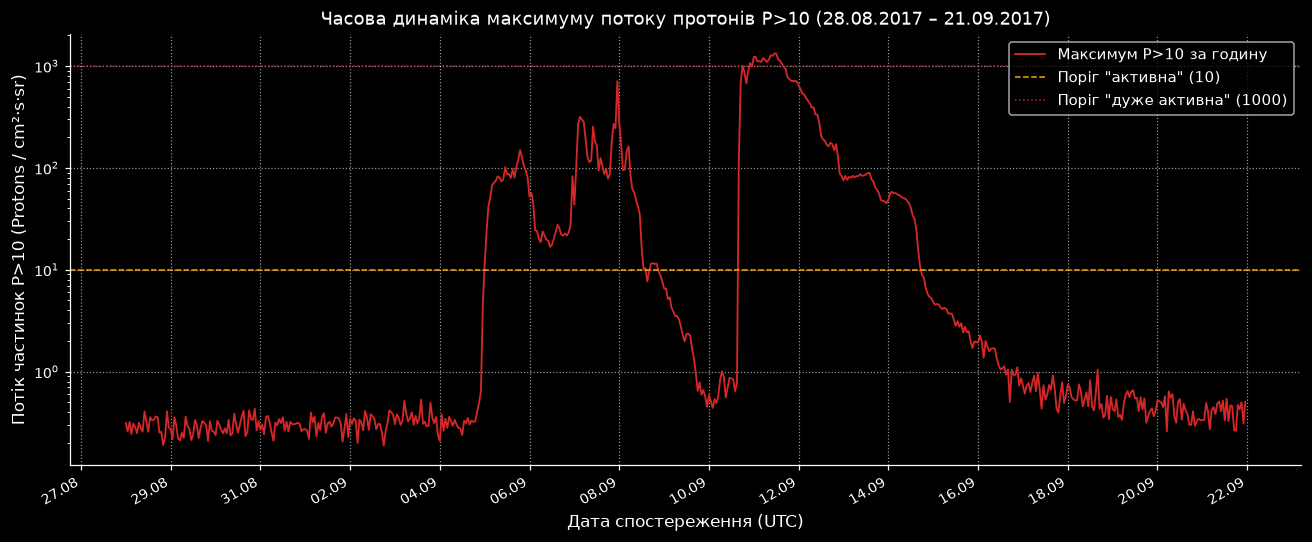

In [24]:
# ВАШ КОД
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(M['ts'], M['p_gt_10_max'], color='tab:red', linewidth=1.2, label='Максимум P>10 за годину')

plt.yscale('log')

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.gcf().autofmt_xdate()

plt.axhline(10, color='orange', linestyle='--', linewidth=1, label='Поріг "активна" (10)')
plt.axhline(1000, color='crimson', linestyle=':', linewidth=1, label='Поріг "дуже активна" (1000)')

plt.title('Часова динаміка максимуму потоку протонів P>10 (28.08.2017 – 21.09.2017)', fontsize=12)
plt.xlabel('Дата спостереження (UTC)', fontsize=11)
plt.ylabel('Потік частинок P>10 (Protons / cm²·s·sr)', fontsize=11)
plt.grid(True, which='major', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

**Висновок:**
Протягом більшої частини періоду потік протонів P>10 перебував на низькому стабільному рівні близько 0.2, проте 4–13 вересня спостерігалося різке зростання на чотири порядки з подоланням порогів активності через серію потужних сонячних спалахів.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

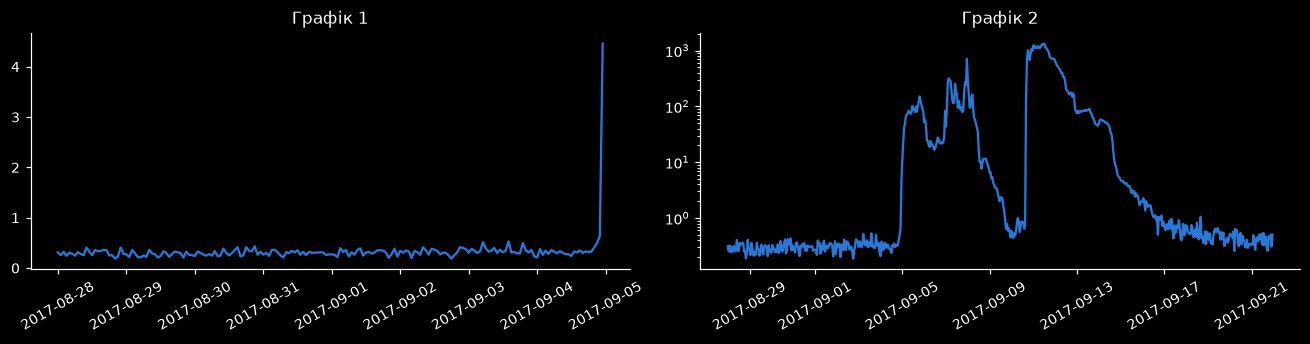

In [25]:
СТОВПЕЦЬ = 'p_gt_10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:
Протягом тижня космічна погода була спокійною (потік коливався біля нульового фону 0.2–0.5), а 4 вересня відбувся раптовий сплеск до значень близько 4.5, що без ширшого контексту виглядає або як локальна аномалія/збій сенсора наприкінці спостережень, або як завершений невеликий спалах.

2. Висновок з другого графіка:
У вересні 2017 року сталася масштабна сонячна буря з двома потужними хвилями екстремального радіаційного шторму (4–9 та 10–13 вересня), під час яких потік протонів зріс більш ніж у 3000 разів від фону (перевищивши позначку 10^3), а сплеск до 4.5 на початку вересня був лише першим моментом зародження бурі.

3. Дві відмінності між ними:
 - Діапазон часу. Графік 1 охоплює лише перший тиждень з 28 серпня по 4 вересня (вікно), тоді як Графік 2 показує весь масив спостережень за повні 25 діб, включаючи головні піки активності 10–12 вересня.

 - Масштаб осі. На Графіку 1 використано звичайну лінійну шкалу, а на Графіку 2 застосовано логарифмічний масштаб (ax[1].set_yscale('log')), завдяки чому можна одночасно розгледіти і фонові значення нижче 1, і пікові викиди понад 1000.

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

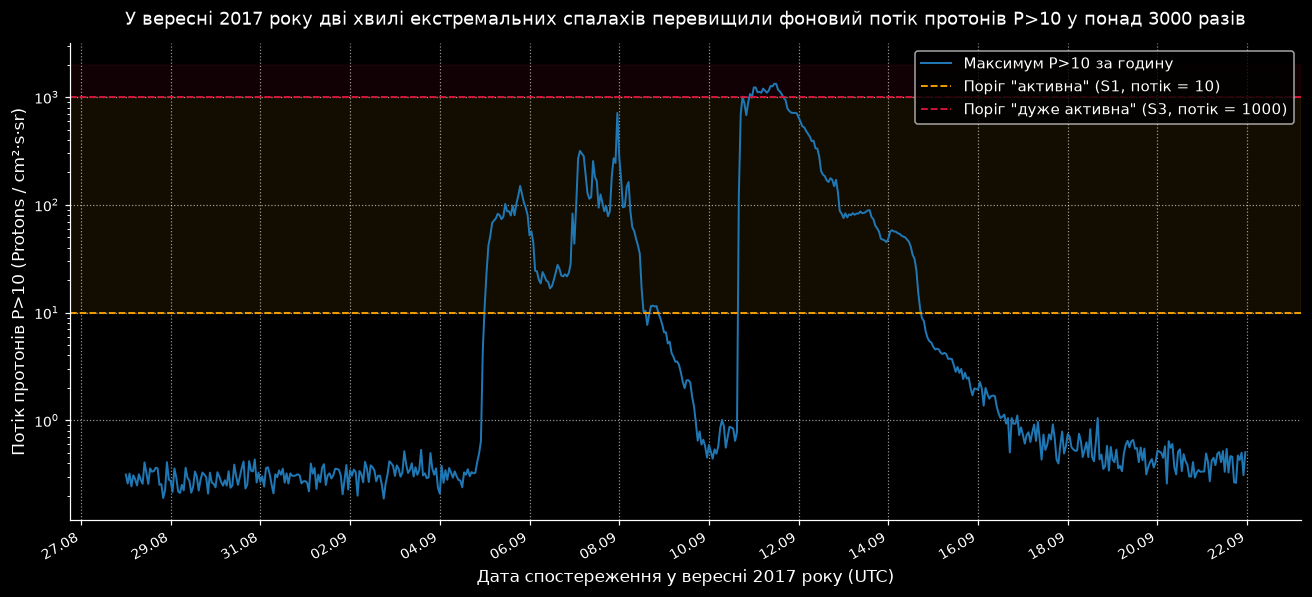

In [26]:
# ВАШ КОД
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5.5))

plt.plot(
    M['ts'],
    M['p_gt_10_max'],
    color='#1f77b4',
    linewidth=1.3,
    label='Максимум P>10 за годину'
)

plt.yscale('log')

plt.axhline(10, color='orange', linestyle='--', linewidth=1.2, label='Поріг "активна" (S1, потік = 10)')
plt.axhline(1000, color='crimson', linestyle='--', linewidth=1.2, label='Поріг "дуже активна" (S3, потік = 1000)')

plt.axhspan(10, 1000, color='orange', alpha=0.08)
plt.axhspan(1000, 2000, color='crimson', alpha=0.08)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.gcf().autofmt_xdate()

plt.title('У вересні 2017 року дві хвилі екстремальних спалахів перевищили фоновий потік протонів P>10 у понад 3000 разів', fontsize=12, pad=12)
plt.xlabel('Дата спостереження у вересні 2017 року (UTC)', fontsize=11)
plt.ylabel('Потік протонів P>10 (Protons / cm²·s·sr)', fontsize=11)

plt.grid(True, which='major', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** Графік побудовано як часовий ряд за повний період вибірки (25 діб) із логарифмічною шкалою по осі Y та горизонтальними порогами 10 і 1000.Такий вигляд обрано з кількох причин. По-перше, повний часовий контекст, бо відображено увесь місяць,а це унеможливлює маніпуляцію вибіркою й чесно показує як тривалий спокійний стан середовища, так і розвиток, піки та згасання двох окремих хвиль сонячного шторму (4–8 та 10–13 вересня). По-друге, логарифмічна шкала, де діапазон значень охоплює понад чотири порядки (від фонових ~0.2 до екстремальних >1000). Лінійна шкала перетворила б 90% часу спостережень на невидиму лінію на рівні нуля, тоді як логарифмічна дозволяє одночасно аналізувати і структуру фонового шуму, і точну динаміку спалахів. По-третє, нанесення ліній 10 та 1000 дає фізичну шкалу інтерпретації, показуючи, коли потік досягав рівнів слабкої та сильної радіаційної небезпеки для космічних апаратів і зв'язку.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**
    На графіку 1 Етапу 5 можна спостерігати, що для погодного потоку P>50 медіанне та середня значення різняться у ~80 разів(де mean > median). Це вказує на факт наявності викидів у вибірці, що ми чітко можемо відстежити на графіку, де попри те, що більшість значень лежать у околі -1.1(0.08 без логарифма) +- 0.2, наявні одиничні(до десяти) викиди за межами 2.0 по логарифмічній шкалі(тобто понад у 1000 разів більші за медіанне значення)

**Спостереження 2:**
    За графіком 3 з Етапу 5 можна спостерігати, що кореляція між потоком електронів E>0.8 та протонів P>10 є нелінійною. Де на невеликих значеннях щільності потоку протонів(у межах 0.2-0.5 Protons/(cm^2 * s * sr)) вони практично не залежать від коливання значення цілності потоку електронів. При більшостях лінійності теж не спостерігається зі значним розкидом значень корекляції

**Спостереження 3:**
    За графіком завдання 6.2 можна спостерігати, що сплеск активності у вересні 2017 року мав чітку двохвилюву структуру з піками 4–8 вересня (значення потоку P>10 понад 100) та 10–13 вересня (потік перевищив 1000, досягнувши порогу найсильнішої радіаційної небезпеки), між якими спостерігався короткочасний спад майже до фонового рівня.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [27]:
# ВАШ КОД
max_f107_row = M.loc[M['radio_flux_10_7'].idxmax()]
max_f107_date = max_f107_row['ts'].strftime('%Y-%m-%d')
max_f107_val = max_f107_row['radio_flux_10_7']

max_p50_row = M.loc[M['p_gt_50_mean'].idxmax()]
max_p50_date = max_p50_row['ts'].strftime('%Y-%m-%d')
max_p50_time = max_p50_row['ts'].strftime('%Y-%m-%d %H:%M')
max_p50_val = max_p50_row['p_gt_50_mean']

print(f"Максимальний радіопотік F10.7: {max_f107_val} sfu, дата: {max_f107_date}")
print(f"Пік потоку P>50 (середнє значення): {max_p50_val:.2f} Protons/(cm²·s·sr), дата/час: {max_p50_time}")

Максимальний радіопотік F10.7: 140 sfu, дата: 2017-09-04
Пік потоку P>50 (середнє значення): 180.83 Protons/(cm²·s·sr), дата/час: 2017-09-11 01:00


**Відповідь 7.2:**
Найбільший радіопотік F10.7 спостерігався 4 вересня 2017 року (140 sfu), і цей день не збігається з піком потоку протонів P>50, максимум якого (180.83 Protons/(cm²·s·sr)) було зафіксовано на тиждень пізніше — 11 вересня 2017 року о 01:00.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [28]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'код, перевірено',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Доводилося виправляти звернення до конкретних стовпців та використання конкретних метрик(тобто де було mean, а повинно було бути median). Усунено технічну проблему з сіткою на діаграмі розсіювання (Графік 3), було замінено надмірно густу логарифмічну сітку which=`both` на основну which=`major`(значення по дефолту)'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [29]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Климчук Юрій
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                код, перевірено
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Доводилося виправляти звернення до конкретних стовпців та використання конкретних метрик(тобто де було mean, а повинно було бути median). Усунено технічну проблему з сіткою на діаграмі розсіювання (Графік 3), було замінено надмірно густу логарифмічну сітку which=`both` на основну which=`major`(зн

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [30]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [31]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
